In [4]:
# importing all the libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import ImageGrid
import copy
import random
import pandas as pd
import math
import scipy
from scipy.stats import norm, expon
from scipy.linalg import null_space
import pandas as pd
import matplotlib as mpl

import os
cwd = os.getcwd()

In [5]:
# define variables
data_seed = 1223
burnin = 10000 #10k
n_after_burnin = 10000 #10k
delta_t = 0.3

#T=60 gives 200 delta_y
T = 120
n_data = 400
n_chains = 4
n_sim = 1

V_F = 2000
V_B = -1500
V = np.array([V_F, V_B])
Lambda = np.array([1, 0.5, 0.6, 0.2])
log_Lambda = np.log(Lambda)
Pij = np.array([0.0, 0.0, 0.7])
sigma = 50.0
n_param = {'4two_to_3':7, '4two_to_4two':8}

correlated = True
up_to_switches = 1
track = True

plots = False
save = True
all_plots = False
plot_posteriors_grid = False
plot_fit = False
plot_fit_median = False

In [6]:
theta_true = {'4two_to_3':[2000, -1500, np.log(1.0), np.log(0.5), np.log(0.15), 0.5, 50], 
              '4two_to_4two':[2000, -1500, np.log(1.0), np.log(0.5), np.log(0.6),
                              np.log(0.2), 0.5, 50]}

In [7]:
list_of_folders = ['4two_to_3', '4two_to_4two']

parameter_names = {'4two_to_3':['v1', 'v2', 'log(lambda1)', 'log(lambda2)',
                                   'log(lambda3)', 'p31', 'sigma'],
                   '4two_to_4two':['v1', 'v2', 'log(lambda1)', 'log(lambda2)',
                                   'log(lambda3)', 'log(lambda4)', 'p41', 'sigma']}

parameter_names_tex = {'4two_to_3':[r'$v_1$', r'$v_2$', r'log$(\lambda_1)$',
                                    r'log$(\lambda_2)$', r'log$(\lambda_3)$',
                                    r'$p_{31}$',
                                    r'$\sigma$'], 
                       '4two_to_4two':[r'$v_1$', r'$v_2$', r'log$(\lambda_1)$',
                                       r'log$(\lambda_2)$', r'log$(\lambda_3)$',
                                       r'log$(\lambda_4)$', r'$p_{41}$', r'$\sigma$']}

In [8]:
#importing the log_pi results of the inference
#this can take a while
#seed number is printed as they get imported
log_pi = {'4two_to_3':[None for _ in range(100)],
          '4two_to_4two':[None for _ in range(100)]}

for fold_name in list_of_folders:
    print("Importing logpi - folder", fold_name, "seed")
    for seed in range(100):
        print(str(seed))
        log_pi[fold_name][seed] = np.array(pd.read_csv("RESULTS_"+fold_name+"_pij/MCMC, seed "+str(seed)+", log_pi , burnin=1000, n_after_burnin=10000", index_col=0)).flatten()

Importing logpi - folder 4two_to_3 seed
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
Importing logpi - folder 4two_to_4two seed
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [9]:
#Computing the AIC and the BIC
#AIC = 2k - 2log(maxL)
AICs = [[], []]

for fold_ind in range(2):
    fold_name = list_of_folders[fold_ind]
    AICs[fold_ind] = [2*n_param[fold_name]-np.max(log_pi[fold_name][seed])
                       for seed in range(100)]

AICs = np.array(AICs)

AIC_choice = np.zeros(2)
for seed in range(100):
    AIC_choice[np.argmin([AICs[i, seed] for i in range(2)])] += 0.01
    

#{BIC} = k log(N) - 2log(maxL))
BICs = [[], []]

for fold_ind in range(2):
    fold_name = list_of_folders[fold_ind]
    BICs[fold_ind] = [n_param[fold_name]*np.log(n_data)-np.max(log_pi[fold_name][seed])
                       for seed in range(100)]

BICs = np.array(BICs)

BIC_choice = np.zeros(2)
for seed in range(100):
    BIC_choice[np.argmin([BICs[i, seed] for i in range(2)])] += 0.01

AIC choice [0.64 0.36]
BIC choice [0.99 0.01]


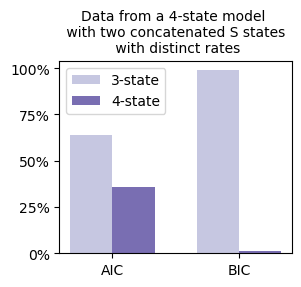

In [10]:
#Figure 6 panel E
print('AIC choice', AIC_choice)
print('BIC choice', BIC_choice)

colors_list = mpl.colormaps['Purples'](np.linspace(0, 1, 4))[1:3]
positions = [-0.2,0.2]
model_names = ['3-state', '4-state']

plt.figure(figsize=(3,2.5))

for i in range(2):
    j = positions[i]
    plt.bar(j, AIC_choice[i]*100, width=0.4,
            label=model_names[i], color=colors_list[i])

plt.legend()

for i in range(2):
    j = positions[i]
    plt.bar(j+1.2, BIC_choice[i]*100, width=0.4,
            label=model_names[i], color=colors_list[i])

plt.xticks([0,1.2], ['AIC', 'BIC'])
plt.yticks([0,25,50,75,100],['0%','25%','50%','75%','100%'])
plt.title('Data from a 4-state model \n with two concatenated S states \n with distinct rates',
          fontsize=10)
plt.savefig("frequency_model_selected_with_criteria_4two_vs_3.png", format="png", dpi=1200,
            bbox_inches="tight")
plt.show()

In [11]:
theta_all = {'4two_to_3':[[] for _ in range(100)], '4two_to_4two':[[] for _ in range(100)]}
theta_best = {'4two_to_3':[None for _ in range(100)], '4two_to_4two':[None for _ in range(100)]}

#importing the data - this does take a while
for fold_name in list_of_folders:
    print("Importing theta - folder", fold_name, "seed")
    for seed in range(100):
        print(str(seed))
        for param in parameter_names[fold_name]:
            theta_all[fold_name][seed] += [np.array(pd.read_csv("RESULTS_"+fold_name+"_pij/MCMC, seed "+str(seed)+", parameter "+param+", burnin=1000, n_after_burnin=10000", index_col=0)).flatten()]
        theta_all[fold_name][seed] = np.array(theta_all[fold_name][seed])
        theta_best[fold_name][seed] = theta_all[fold_name][seed][:, np.argmax(log_pi[fold_name][seed])]

Importing theta - folder 4two_to_3 seed
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
Importing theta - folder 4two_to_4two seed
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


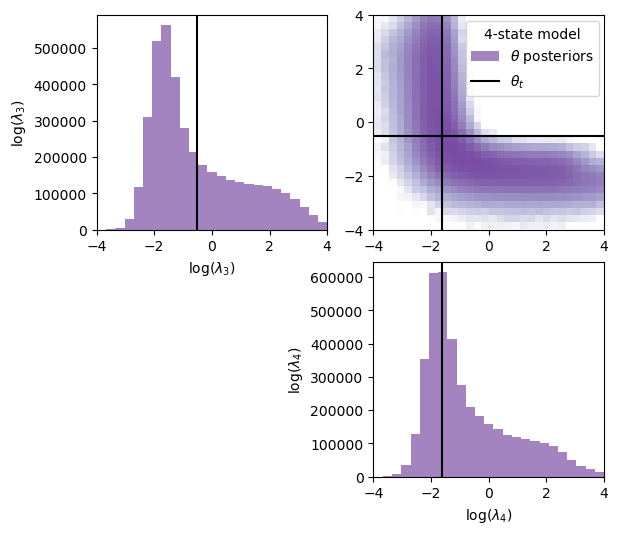

In [21]:
#Figure 7 panel A

priors = {'4two_to_4two':[[0.0, 2.0*V_F], [2.0*V_B, 0.0], [-4.0, 4.0], [-4.0, 4.0],
                          [-4.0, 4.0], [-4.0, 4.0], [0, 1], [0.0, 2.0*sigma]],
          '4two_to_3':[[0.0, 2.0*V_F], [2.0*V_B, 0.0], [-4.0, 4.0], [-4.0, 4.0],
                          [-4.0, 4.0], [0,1], [0.0, 2.0*sigma]]}

for fold_name in ['4two_to_4two']:

    fig, ax = plt.subplots(2, 2,
                           figsize=(7,6))
    plt.subplots_adjust(wspace=0.2, hspace=0.15)
    for i in [4,5]:
        ax[i-4,i-4].set_ylabel(parameter_names_tex[fold_name][i])
        ax[i-4,i-4].set_xlabel(parameter_names_tex[fold_name][i])

    for i in [4,5]:
        ax[i-4,i-4].hist(np.array([theta_all[fold_name][seed][i]
                                   for seed in range(100)]).flatten(),
                         bins=25, alpha=0.6,
                         label=r'$\theta$ posteriors', color='rebeccapurple')
        ax[i-4,i-4].axvline(theta_true[fold_name][i], color='black',
                        label=r'$\theta_t$')
        
        ax[i-4,i-4].set_xlim(priors[fold_name][i])

    for i in [4,5]:
        for j in range(4,i):
            ax[i-4,j-4].axis('off')
        for j in range(i+1,6):
            #plt.title('Checking correlations')
            ax[i-4,j-4].hist2d(np.array([theta_all[fold_name][seed][j]
                                   for seed in range(100)]).flatten(),
                           np.array([theta_all[fold_name][seed][i]
                                   for seed in range(100)]).flatten(), density=True, bins=30,
                           norm=colors.LogNorm(), alpha=0.7, cmap='Purples')
            
            ax[i-4,j-4].set_xlim(priors[fold_name][j])
            ax[i-4,j-4].set_ylim(priors[fold_name][i])
            
            ax[i-4,j-4].axvline(theta_true[fold_name][j], color='black')
            ax[i-4,j-4].axhline(theta_true[fold_name][i], color='black')
    plt.subplots_adjust(right=0.85)
    plt.legend(title='4-state model', bbox_to_anchor=(0.98, 2.12), loc='upper right', borderaxespad=0)
    plt.savefig("compare_lambda_3_4_posteriors_with_priors_"+fold_name+".png", format="png", dpi=1200, bbox_inches="tight")
    plt.show()

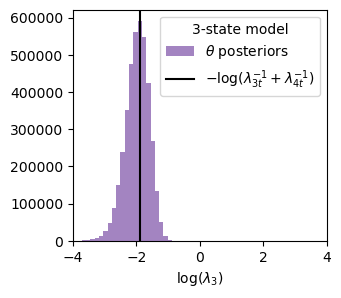

In [23]:
#Figure 7 panel C
for fold_name in ['4two_to_3']:

    fig, ax = plt.subplots(figsize=(3.5,3))
    plt.subplots_adjust(wspace=0.35, hspace=0.2)
    for i in [4]:
        #ax.set_ylabel(parameter_names_tex[fold_name][i])
        ax.set_xlabel(parameter_names_tex[fold_name][i])
        
        ax.set_xlim(priors[fold_name][i])

    for i in [4]:
        ax.hist(np.array([theta_all[fold_name][seed][i]
                                   for seed in range(100)]).flatten(), bins=25, alpha=0.6,
                     label=r'$\theta$ posteriors', color='rebeccapurple')
        ax.axvline(theta_true[fold_name][i], color='black',
                   label=r'$-$log$(\lambda_{3t}^{-1} + \lambda_{4t}^{-1})$')

    plt.subplots_adjust(right=0.85)
    plt.legend(title='3-state model', loc='upper right')
    plt.savefig("compare_lambda_3_4_posteriors_with_priors_"+fold_name+".png", format="png", dpi=1200, bbox_inches="tight")
    plt.show()